In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

import glob, pyBigWig, shutil, os
import pandas as pd

import sys
sys.path.append('crestgv/')
from crestgv import crestgv

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

### Data

In [3]:
rounds  = sorted(glob.glob("CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round*"))
crestgv  = sorted(glob.glob("CREST-GV_test/Bcell_GO_0035456/statistics_CREST-GV.csv"))

In [4]:
rounds

['CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round1.csv',
 'CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round2.csv',
 'CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round3.csv',
 'CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round4.csv',
 'CREST-GV_test/Bcell_GO_0035456/rounds/statistics_intermediate_round5.csv']

In [5]:
crestgv

['CREST-GV_test/Bcell_GO_0035456/statistics_CREST-GV.csv']

### Variation Plots

In [6]:
dfs = []
for r in rounds:
    df = pd.read_csv(r, sep='\t', index_col=0)
    df = df[['CREST-GV']]
    dfs.append(df)
    
df = pd.concat(dfs)

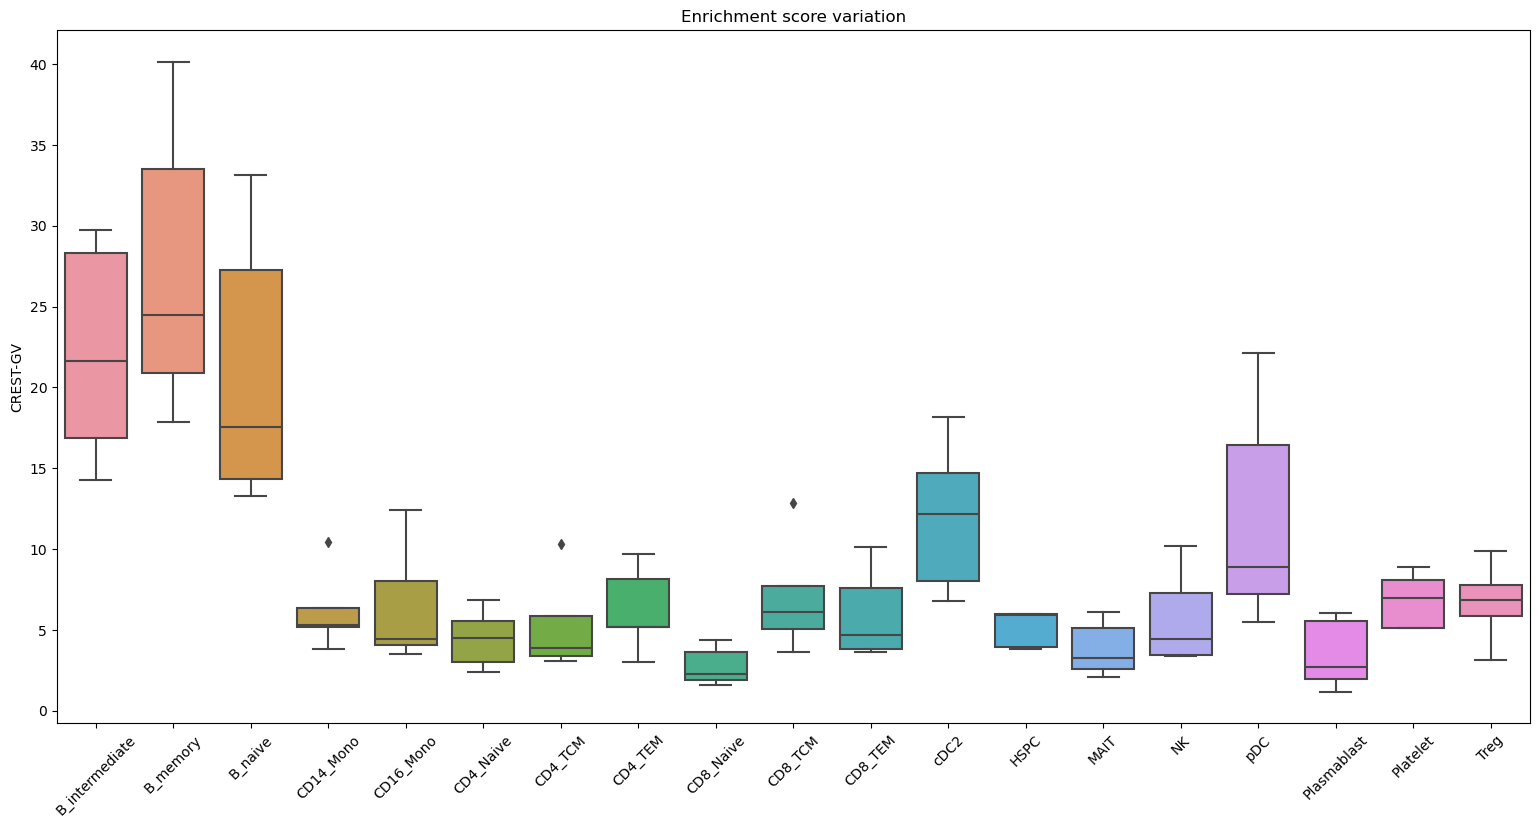

In [7]:
f, ax = plt.subplots(1,1,figsize=(len(set(df.index.tolist())), 9))
sns.boxplot(data=df, x=df.index, y='CREST-GV', ax=ax)
ax.tick_params(axis='x', rotation=45)
plt.title("Enrichment score variation")
plt.show()

### Heatmap plots

In [8]:
dfs = []
for r in rounds:
    df = pd.read_csv(r, sep='\t', index_col=0)
    df = df[['CREST-GV']]
    name = r.split("/")[-1].replace(".csv", "")
    df.index = df.index + "_%s"%name
    dfs.append(df)
    
df = pd.concat(dfs)

print('min value:    ', df['CREST-GV'].min())
print('mean value:   ', df['CREST-GV'].mean())
print('median value: ', df['CREST-GV'].median())
print('max value:    ', df['CREST-GV'].max())

min value:     1.1820278200138263
mean value:    9.001688445727956
median value:  5.969207056577951
max value:     40.149105997339205


In [9]:
vmax = 0
for df in dfs:
    if df['CREST-GV'].max() > vmax:
        vmax = df['CREST-GV'].max()

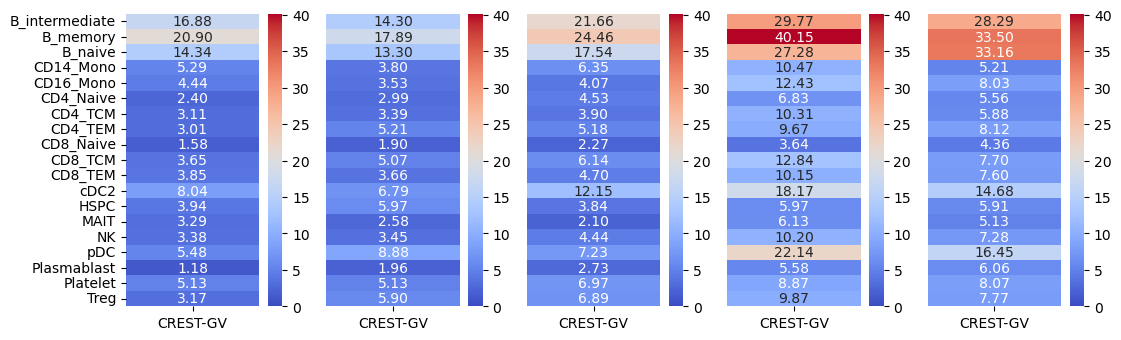

In [10]:
f, ax = plt.subplots(1,len(dfs),figsize=(len(dfs)*2.5,dfs[0].shape[0]/5))
for i, df in enumerate(dfs):
    if i == 0:
        df.index = df.index.str.replace("_statistics_intermediate_round1", "")
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
    else:
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], yticklabels=False, fmt='.2f', cmap='coolwarm', vmin=0, vmax=vmax)
plt.show()

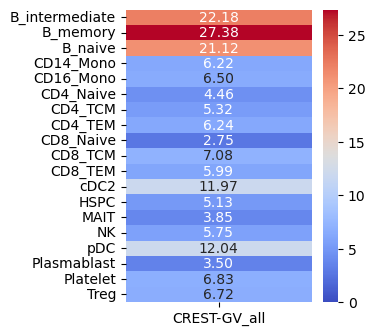

In [11]:
df = pd.read_csv(crestgv[0], sep='\t', index_col=0)
f, ax = plt.subplots(1,1,figsize=(3,df.shape[0]/5))
ax = sns.heatmap(df, annot=True, ax=ax, fmt='.2f', cmap='coolwarm', vmin=0)
plt.show()